# MLP from Scratch

用 numpy 从零实现一个多层感知机（含前向、反向、训练），再与 torch autograd 对拍梯度。本课把 calculus 05 的反向传播推导变成可以跑起来的代码。


## 0. 环境配置与导入


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib

matplotlib.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Arial Unicode MS", "Microsoft YaHei", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False

print("PyTorch version:", torch.__version__)
torch.manual_seed(42)


PyTorch version: 2.13.0


## 1. 数据集：两个高斯簇


造一个可复现的二维二分类数据集（两个高斯簇），后续课程反复使用。真实项目里替换成 `torchvision.datasets` 等即可。


Text(0.5, 1.0, '二维二分类数据集（高斯簇）')

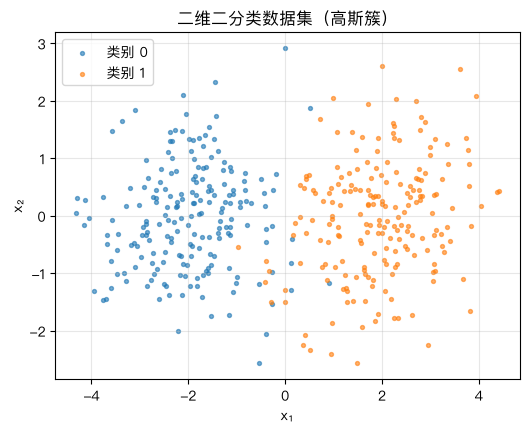

In [2]:
rng = np.random.default_rng(42)
n = 200
X0 = rng.standard_normal((n, 2)) + np.array([-2.0, 0.0])
X1 = rng.standard_normal((n, 2)) + np.array([2.0, 0.0])
X = np.vstack([X0, X1])
y = np.concatenate([np.zeros(n), np.ones(n)])

plt.figure(figsize=(6, 4.5))
plt.scatter(X[y==0, 0], X[y==0, 1], s=8, alpha=0.6, label='类别 0')
plt.scatter(X[y==1, 0], X[y==1, 1], s=8, alpha=0.6, label='类别 1')
plt.xlabel('x₁'); plt.ylabel('x₂'); plt.legend(); plt.grid(alpha=0.3)
plt.title('二维二分类数据集（高斯簇）')


## 2. 网络结构：2-4-1


结构：输入 2 维 → 隐藏层 4 神经元（$\tanh$）→ 输出 1 维（sigmoid）。

$$
\begin{aligned}
z_1 &= W_1 x + b_1, & a_1 &= \tanh(z_1) \\
z_2 &= W_2 a_1 + b_2, & \hat y &= \sigma(z_2)
\end{aligned}
$$

## 3. 反向传播（BCE + sigmoid 的简化）


损失：$L = -\frac{1}{m}\sum\big[y\log\hat y + (1-y)\log(1-\hat y)\big]$。

关键梯度（calculus 08 已验证 $\partial L/\partial z = \hat y - y$）：

$$
\begin{aligned}
\frac{\partial L}{\partial z_2} &= \hat y - y \\
\frac{\partial L}{\partial W_2} &= a_1^\mathsf{T}\,\frac{\partial L}{\partial z_2}, &
\frac{\partial L}{\partial z_1} &= \Big(\frac{\partial L}{\partial z_2}W_2^\mathsf{T}\Big)\odot(1-a_1^2) \\
\frac{\partial L}{\partial W_1} &= x^\mathsf{T}\,\frac{\partial L}{\partial z_1}
\end{aligned}
$$

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

class MLP:
    def __init__(self, dims, seed=0):
        r = np.random.default_rng(seed)
        self.W1 = r.standard_normal((dims[0], dims[1])) * 0.5
        self.b1 = np.zeros(dims[1])
        self.W2 = r.standard_normal((dims[1], dims[2])) * 0.5
        self.b2 = np.zeros(dims[2])

    def forward(self, x):
        self.z1 = x @ self.W1 + self.b1
        self.a1 = np.tanh(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = sigmoid(self.z2)
        return self.a2

    def backward(self, x, y):
        m = len(y)
        dz2 = (self.a2 - y.reshape(-1, 1)) / m        # ∂L/∂z2 = (ŷ−y)/m
        self.dW2 = self.a1.T @ dz2
        self.db2 = dz2.sum(axis=0)
        da1 = dz2 @ self.W2.T
        dz1 = da1 * (1 - self.a1**2)                  # tanh 导数
        self.dW1 = x.T @ dz1
        self.db1 = dz1.sum(axis=0)

    def step(self, lr):
        self.W1 -= lr * self.dW1; self.b1 -= lr * self.db1
        self.W2 -= lr * self.dW2; self.b2 -= lr * self.db2

    def loss(self, x, y):
        a = self.forward(x)
        yy = y.reshape(-1, 1)
        eps = 1e-12
        return -np.mean(yy*np.log(a+eps) + (1-yy)*np.log(1-a+eps))


## 4. 手写梯度 vs torch autograd（对拍）


在**完全相同的权重**下，手写 backward 与 torch autograd 应该给出相同的梯度——这是检验推导正确性的黄金标准。


In [4]:
mlp = MLP([2, 4, 1], seed=0)

# 构造权重完全相同的 torch 模型
tnet = nn.Sequential(nn.Linear(2, 4), nn.Tanh(), nn.Linear(4, 1))
with torch.no_grad():
    tnet[0].weight.copy_(torch.tensor(mlp.W1.T)); tnet[0].bias.copy_(torch.tensor(mlp.b1))
    tnet[2].weight.copy_(torch.tensor(mlp.W2.T)); tnet[2].bias.copy_(torch.tensor(mlp.b2))

xt = torch.tensor(X, dtype=torch.float32); yt = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

# torch 侧
loss_t = F.binary_cross_entropy(torch.sigmoid(tnet(xt)), yt)
loss_t.backward()
gW1_t = tnet[0].weight.grad.T.numpy(); gW2_t = tnet[2].weight.grad.T.numpy()
gb1_t = tnet[0].bias.grad.numpy();     gb2_t = tnet[2].bias.grad.numpy()

# 手写侧
mlp.forward(X); mlp.backward(X, y)

print(f"loss 手写 = {mlp.loss(X, y):.8f}  vs  torch = {loss_t.item():.8f}")
print(f"dW1 最大误差 = {np.abs(mlp.dW1 - gW1_t).max():.2e}")
print(f"dW2 最大误差 = {np.abs(mlp.dW2 - gW2_t).max():.2e}")
print(f"db1 最大误差 = {np.abs(mlp.db1 - gb1_t).max():.2e}")
print(f"db2 最大误差 = {np.abs(mlp.db2 - gb2_t).max():.2e}")


loss 手写 = 0.74248998  vs  torch = 0.74248999
dW1 最大误差 = 2.23e-07
dW2 最大误差 = 2.14e-08
db1 最大误差 = 6.14e-09
db2 最大误差 = 5.67e-09


## 5. 训练循环


训练完成，准确率 = 0.978


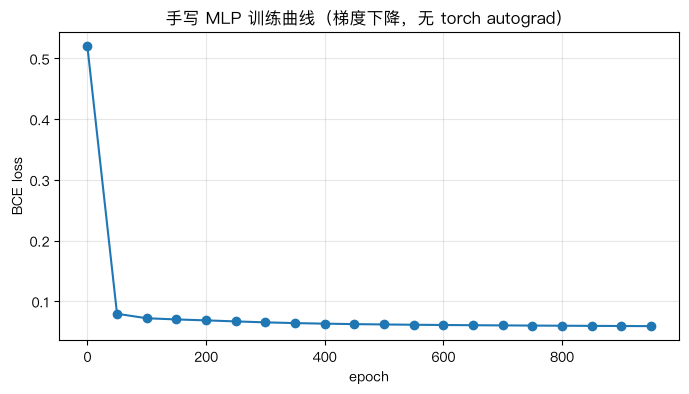

In [5]:
mlp = MLP([2, 4, 1], seed=0)
lr = 0.5
losses = []
for epoch in range(1000):
    mlp.forward(X)
    mlp.backward(X, y)
    mlp.step(lr)
    if epoch % 50 == 0:
        losses.append((epoch, mlp.loss(X, y)))

acc = ((mlp.forward(X).ravel() > 0.5) == y).mean()
print(f"训练完成，准确率 = {acc:.3f}")

plt.figure(figsize=(8, 4))
ep, ls = zip(*losses)
plt.plot(ep, ls, 'o-')
plt.xlabel('epoch'); plt.ylabel('BCE loss')
plt.title('手写 MLP 训练曲线（梯度下降，无 torch autograd）')
plt.grid(alpha=0.3)


## 6. 决策边界可视化


Text(0.5, 1.0, '手写 MLP 的决策面（概率热图）')

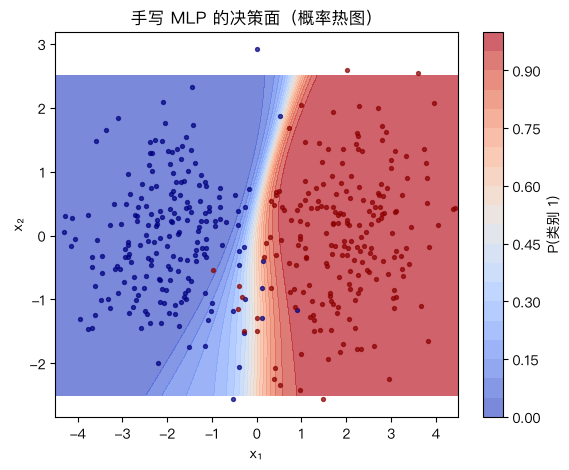

In [6]:
gx = np.linspace(-4.5, 4.5, 200); gy = np.linspace(-2.5, 2.5, 200)
GX, GY = np.meshgrid(gx, gy)
grid = np.stack([GX.ravel(), GY.ravel()], axis=1)
pred = mlp.forward(grid).reshape(GX.shape)

plt.figure(figsize=(6.5, 5))
plt.contourf(GX, GY, pred, levels=20, cmap='coolwarm', alpha=0.7)
plt.colorbar(label='P(类别 1)')
plt.scatter(X[y==0, 0], X[y==0, 1], s=8, c='navy', alpha=0.7)
plt.scatter(X[y==1, 0], X[y==1, 1], s=8, c='darkred', alpha=0.7)
plt.xlabel('x₁'); plt.ylabel('x₂'); plt.title('手写 MLP 的决策面（概率热图）')


## 7. 从手写到框架


手工写一遍的价值：看清每个梯度从哪来。但工程上我们直接 `loss.backward()`——`nn.Linear` 封装了权重/偏置、`F.binary_cross_entropy` 封装了损失、优化器封装了参数更新。后续课程都在"框架"层工作，遇到 bug 时回到本课的手写推导排查。


## 课后练习


1. **改网络**：把隐藏层改成 8 个神经元，重新训练，对比准确率与决策面。
2. **改激活**：把 $\tanh$ 换成 ReLU（注意 $dz_1$ 公式要改），重新对拍梯度。
3. **改损失**：把 sigmoid+BCE 换成"线性输出 + MSE"，推导并修改 backward。
4. **数值梯度**：用中心差分（calculus 02 的方法）验证本课任意一层权重梯度。
5. **思考**：为什么 $\partial L/\partial z_2 = \hat y - y$ 是"预测减真值"这么简单的形式？
